In [2]:
import os

import hydra
import torch

from src.data import get_dataloader
from src.utils import clean_state_dict
from src.utils.factory import create_model_cls

gpus = [6, 7]
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ['CUDA_VISIBLE_DEVICES'] = ','.join(str(e) for e in gpus)


def load_checkpoint(model, checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    state_dict = clean_state_dict(checkpoint['state_dict'])
    model.load_state_dict(state_dict)


methods = ['Add', 'Sub']
architecture = ['33', '333', 'InceptionV1', 'InceptionV2', 'InceptionV3']
weight_root = 'weights'

with hydra.initialize(config_path='configs', version_base='1.3'):
    cfg = hydra.compose(config_name='sub_imagenet', overrides=['local_rank=0', 'train.batch_size=100'])

device = torch.device(f'cuda:{cfg.local_rank}') if torch.cuda.is_available() else torch.device('cpu')
valid_loader = get_dataloader(cfg)[-1]
data = next(iter(valid_loader))

/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import torch
import os
from tqdm import tqdm
from torch import nn
import copy
import pandas

from functools import reduce


def rsetattr(obj, attr, val):
    pre, _, post = attr.rpartition('.')
    return setattr(rgetattr(obj, pre) if pre else obj, post, val)


def rgetattr(obj, attr):
    return reduce(getattr, [obj] + attr.split('.'))


def forward(model, loader, device):
    pred = list()
    ys = list()
    i = 0
    for data in tqdm(loader, total=len(loader), leave=False):
        x, y = data[0].to(device), data[1].to(device)
        out = model(x)
        pred.append(out.argmax(-1))
        ys.append(y)
        i += 1
        if i == 5:
            break
    return torch.concat(pred), torch.concat(ys)


@torch.no_grad()
def main():
    connectivity = f'{methods[1]}{architecture[3]}'
    model_name = f'resnet50_{connectivity}'
    model = create_model_cls(
        model_name,
        in_channels=cfg.dataset.in_channels,
        num_classes=cfg.dataset.num_classes,
        stem_type=cfg.dataset.name,
    )
    load_checkpoint(model,
                    os.path.join(weight_root, cfg.dataset.name, model_name.split('_')[0], model_name + '.pth.tar'))
    model.eval()
    model.to(device)
    # deploy(model, BasicBlockSub)

    pred, ys = forward(model, valid_loader, device)
    acc = pred.eq(ys).float().mean()
    df = pandas.DataFrame([['origin', acc.detach().cpu().item() * 100]])
    print("origin: ", acc.detach().cpu().item() * 100)

    drop_layers = list()
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Conv2d):
            if 'conv2' in name:
                drop_layers.append((name, module))

    for i, (name,module) in enumerate(drop_layers):
        print(f'[{i}/{len(drop_layers)}] {name}')
        drop_model = copy.deepcopy(model)
        module.weight.data.fill_(0.0)
        rsetattr(drop_model, name, module)

        drop_model.to(device)
        pred, ys = forward(drop_model, valid_loader, device)
        acc = pred.eq(ys).float().mean()
        df = pandas.concat([df, pandas.DataFrame([[name, acc.detach().cpu().item() * 100]])])
        
        del (drop_model)
        
        if i==10:
            break

    df.columns = ['SkipConvName', 'Accuracy']
    print(df.describe())
    print(df)
    # df.to_csv(f'{model_name}.csv')

main()

No pretrained configuration specified for ResNetSub model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.


origin:  87.40000128746033
[0/48] layer1.0.conv2.blocks.kxk.0


[1/48] layer1.0.conv2.blocks.1x3.0


[2/48] layer1.0.conv2.blocks.3x1.0


[3/48] layer1.1.conv2.blocks.kxk.0


...

[7/48] layer1.2.conv2.blocks.1x3.0


[8/48] layer1.2.conv2.blocks.3x1.0


[9/48] layer2.0.conv2.blocks.kxk.0


[10/48] layer2.0.conv2.blocks.1x3.0


        Accuracy
count  12.000000
mean   23.950001
std    33.493786
min     0.000000
25%     0.700000
50%     3.000000
75%    42.200002
max    87.400001
                  SkipConvName   Accuracy
0                       origin  87.400001
0  layer1.0.conv2.blocks.kxk.0  80.400002
0  layer1.0.conv2.blocks.1x3.0  59.600002
0  layer1.0.conv2.blocks.3x1.0  36.400002
0  layer1.1.conv2.blocks.kxk.0  14.800000
0  layer1.1.conv2.blocks.1x3.0   4.400000
0  layer1.1.conv2.blocks.3x1.0   0.800000
0  layer1.2.conv2.blocks.kxk.0   0.400000
0  layer1.2.conv2.blocks.1x3.0   0.400000
0  layer1.2.conv2.blocks.3x1.0   0.000000
0  layer2.0.conv2.blocks.kxk.0   1.200000
0  layer2.0.conv2.blocks.1x3.0   1.600000


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np

import copy
from torch import nn
import scienceplots


pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Custom Color
g20_categorical = ["#3366cc", "#dc3912", "#ff9900", "#109618", "#990099", "#0099c6", "#dd4477", "#66aa00", "#b82e2e",
                   "#316395", "#994499", "#22aa99", "#aaaa11", "#6633cc", "#e67300", "#8b0707", "#651067", "#329262",
                   "#5574a6", "#3b3eac"]
science = ['#0C5DA5', '#FF2C00', '#FF9500', '#00B945', '#845B97', '#474747', '#9e9e9e']

# Settings
plt.style.use(['science', 'ieee'])
# plt.figure(figsize=(4, 5), dpi=300)
# Custom Settings
plt.rcParams.update({
    'axes.prop_cycle': "cycler('color', ['#0C5DA5', '#FF2C00', '#FF9500','#00B945', '#845B97', '#474747', '#9e9e9e'])",
    'xtick.major.size': 2.0,
    'ytick.major.size': 2.0,
    'xtick.minor.visible': False,
    'xtick.top': False,
    'xtick.bottom': True,
    'ytick.minor.visible': False,
    'ytick.right': False,
    'figure.edgecolor': '#0e1111',
    'axes.axisbelow': True,
    'svg.fonttype': 'none',
    'text.usetex': False,
    'font.family': ['sans-serif']
})
origin_rc_param = copy.deepcopy(plt.rcParams)

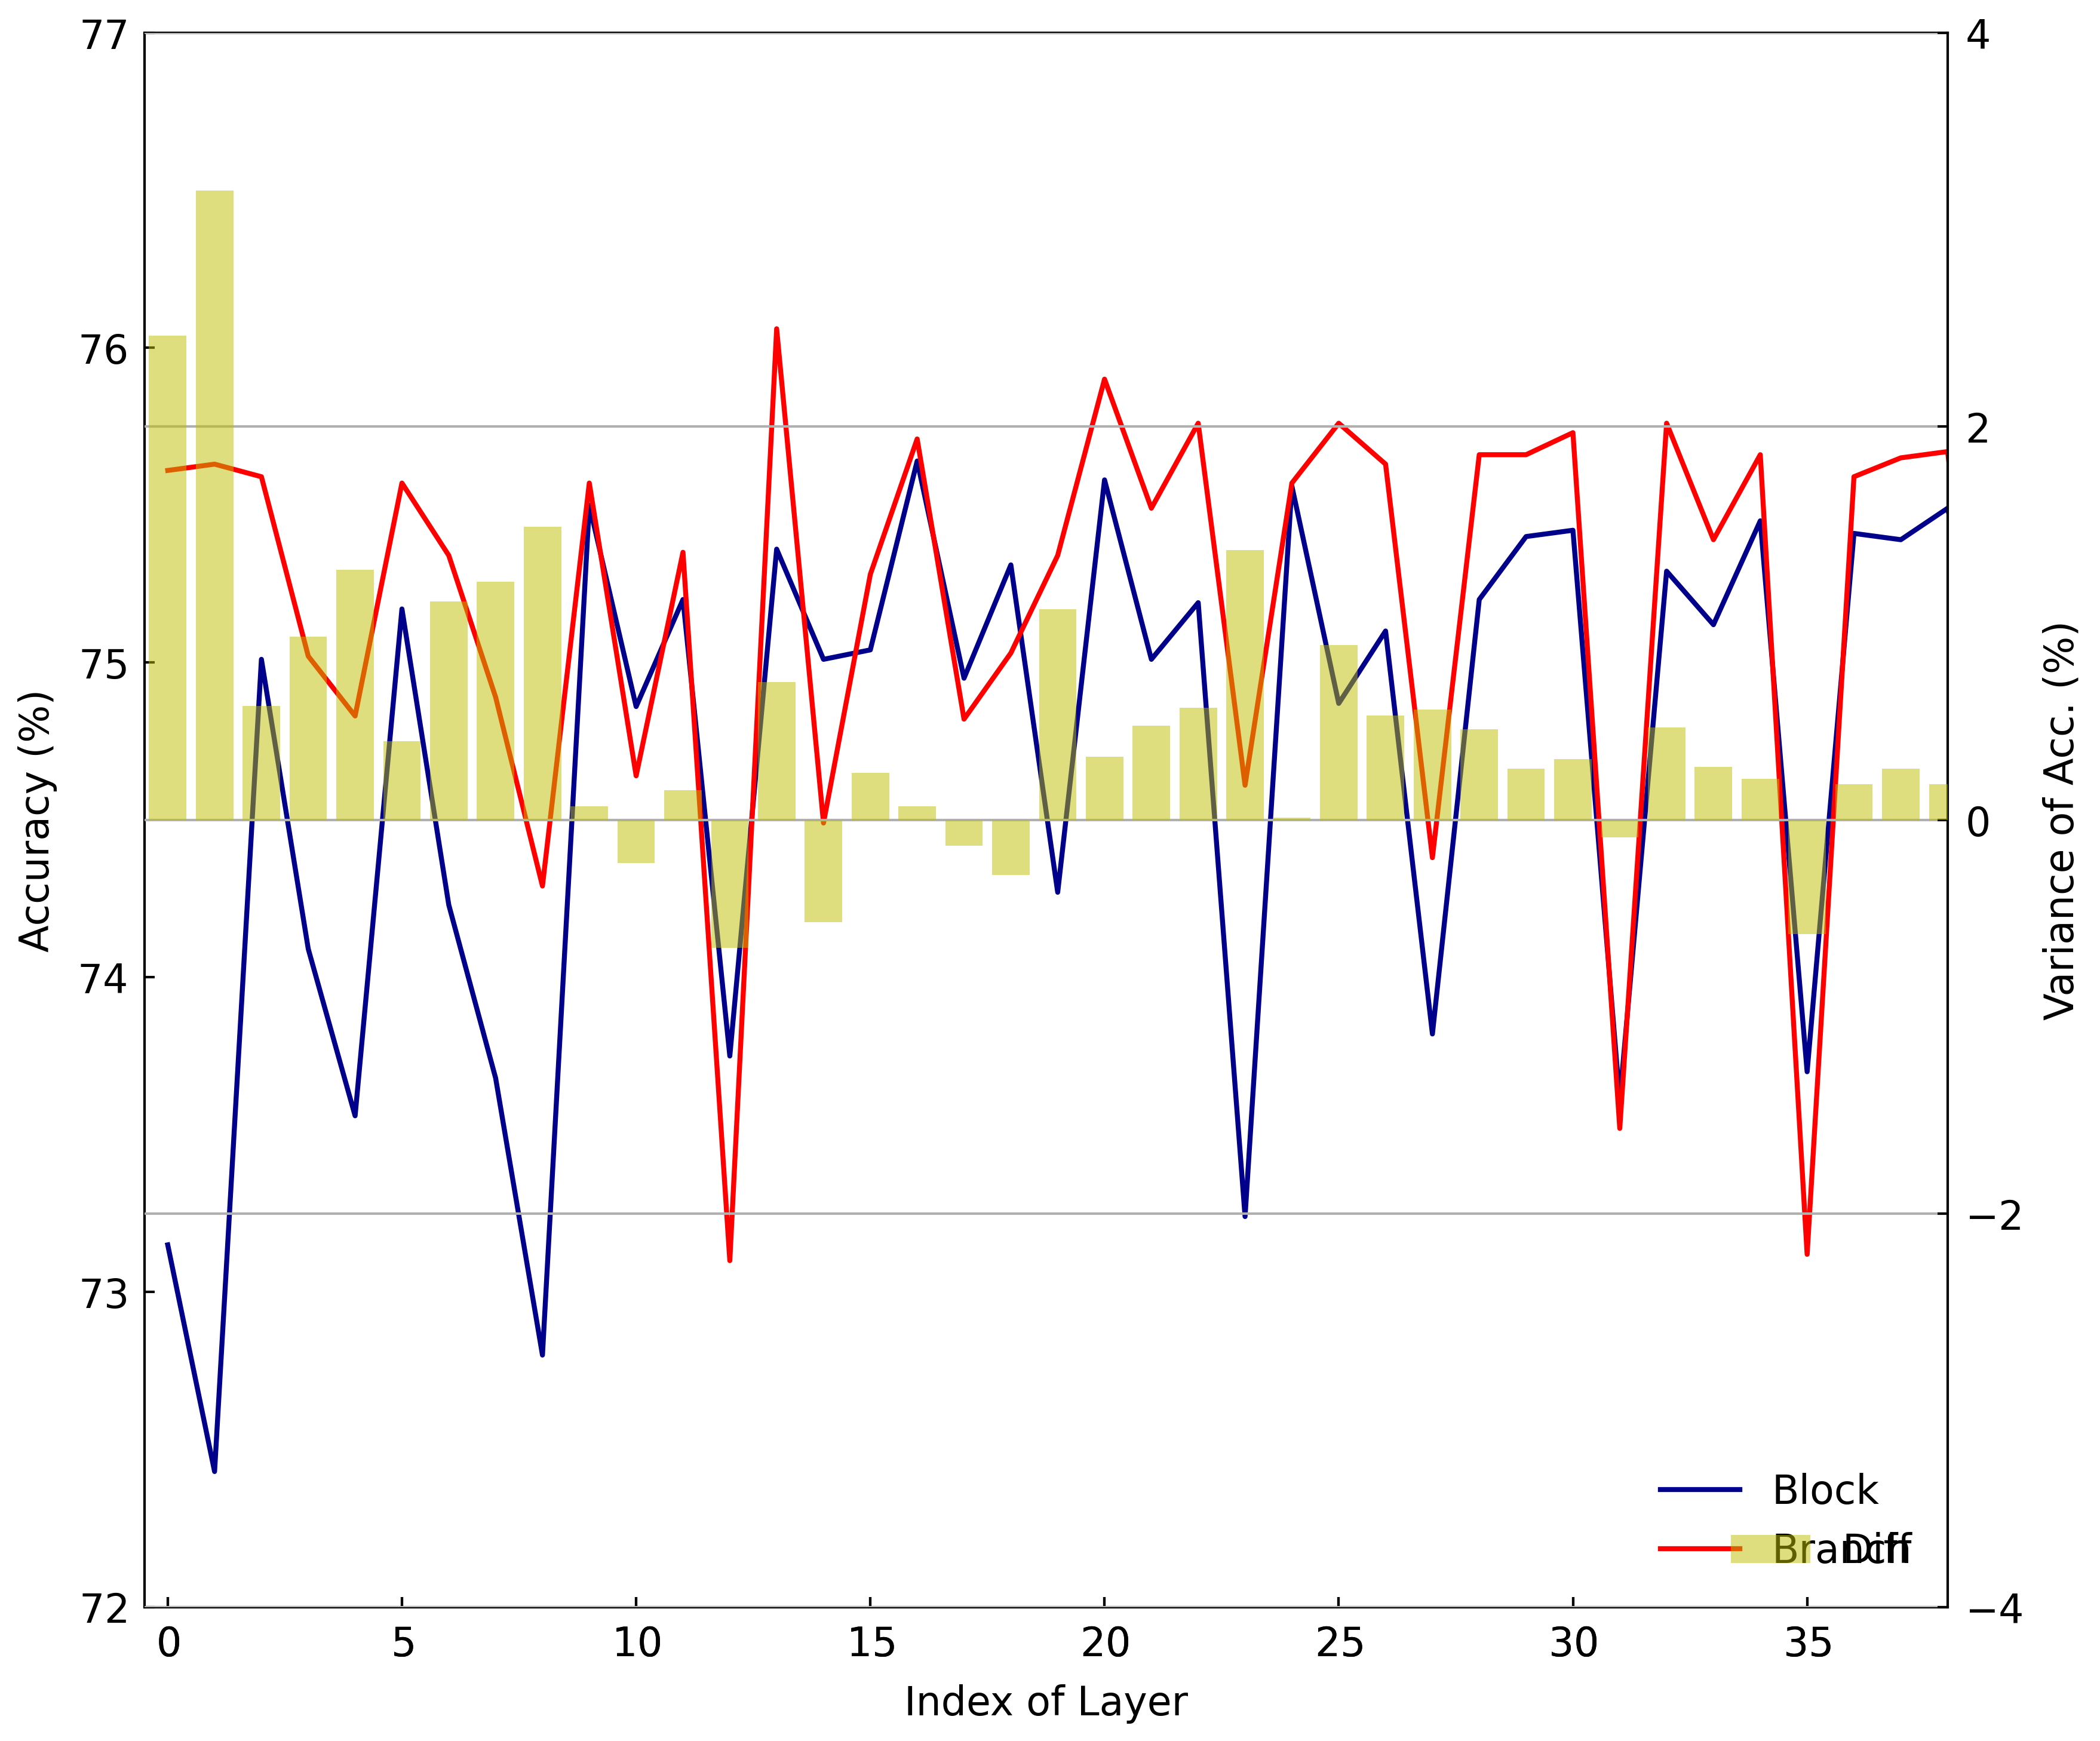

In [45]:
import pandas as pd

df_add = pd.read_csv('assets/droppath_resnet50_AddInceptionV3_cifar.csv')
df_add = df_add.drop('Unnamed: 0', axis=1)

df_sub = pd.read_csv('assets/droppath_resnet50_SubInceptionV3_cifar.csv')
df_sub = df_sub.drop('Unnamed: 0', axis=1)

acc_add = df_add['Accuracy'][1:].to_list()
acc_sub = df_sub['Accuracy'][1:].to_list()
names = df_sub['SkipConvName'][1:].to_list()

# using_idx = list(range(len(acc_add)))
using_idx = list()
for i, (add, sub) in enumerate(zip(acc_add, acc_sub)):
    if sub > 72 and add > 72:
        using_idx.append(i)
# using_idx = using_idx[:-15]

acc_add = list(map(lambda x: acc_add[x], using_idx))
acc_sub = list(map(lambda x: acc_sub[x], using_idx))
names = list(map(lambda x: names[x], using_idx))

fig = plt.figure(figsize=(6, 5))
ax=fig.add_subplot(111, label='1')
ax2=fig.add_subplot(111, label='2', frame_on=False)

ax.plot(acc_add, color='darkblue', label='Block')
ax.plot(acc_sub, color='red', label='Branch')

diff = np.array(acc_sub) - np.array(acc_add)
ax2.bar(np.arange(diff.size), diff, color='y', linestyle='--', alpha=0.5, label='Diff')
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position('right')
ax2.set_yticks([-4, -2, 0, 2, 4])
# for i, name in enumerate(names):
#     color = None
#     if 'kxk' in name:
#         color = 'yellow'
    # elif '1x1' in name:
    #     color = 'purple'
    # elif '1x3' in name:
    #     color = 'green'
    # elif '3x1' in name:
    #     color = 'orange'
    # if color:
    #     plt.axvspan(i - 1, i, facecolor=color, alpha=0.2)

ax2.grid(True, axis='y')
plt.xlabel('Index of Layer')
ax.set_ylim(72,77)
ax.set_xlim(-0.5,38)
ax2.set_xlim(-0.5,38)
ax.set_ylabel('Accuracy (%)')
ax2.set_ylabel('Variance of Acc. (%)')

ax.legend(loc='lower right', ncols=1)
ax2.legend(loc='lower right', ncols=1)

fig.tight_layout()
plt.savefig(f'assets/droppath.svg', dpi=500)
plt.show()
